In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WineQT.csv")

In [2]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
0


In [5]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

In [6]:
numeric_columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'quality'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

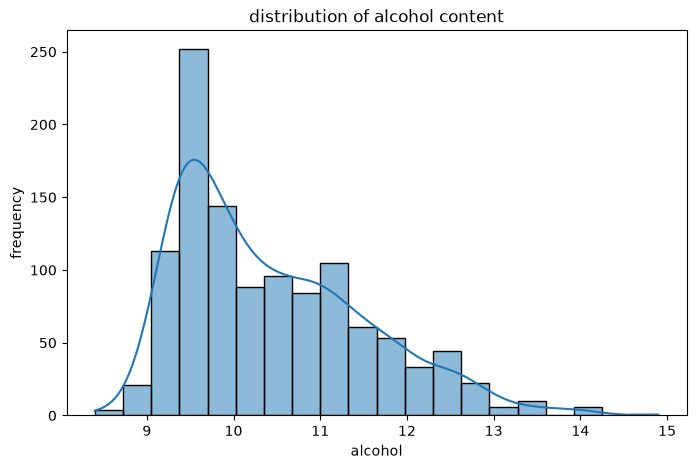

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='alcohol',
    bins=20,
    kde=True
)

plt.title("distribution of alcohol content")
plt.xlabel("alcohol")
plt.ylabel("frequency")
plt.show()

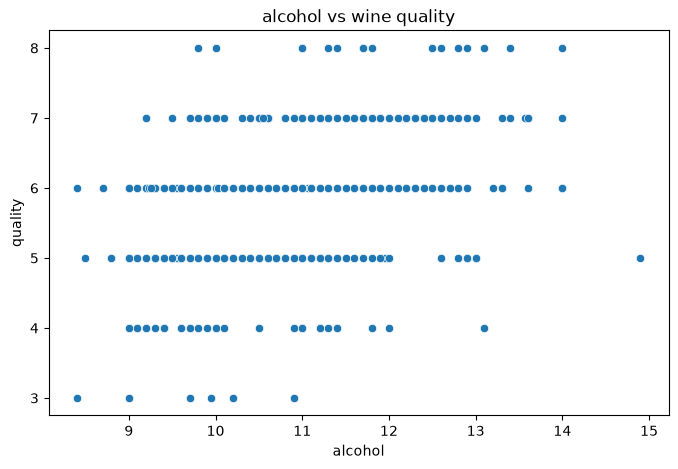

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality'
)

plt.title("alcohol vs wine quality")
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.show()

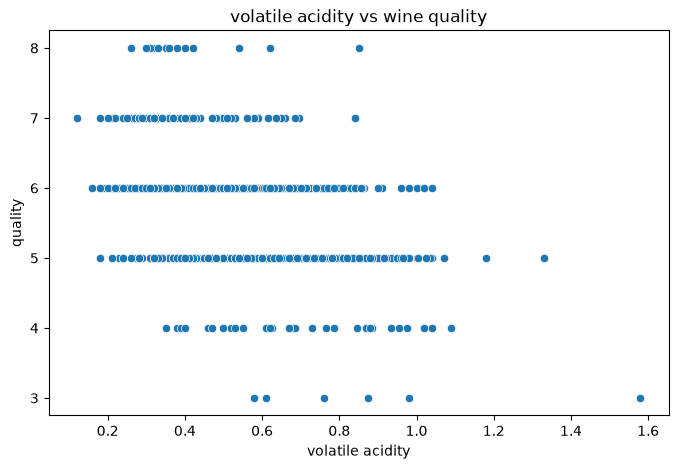

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='volatile acidity',
    y='quality'
)

plt.title("volatile acidity vs wine quality")
plt.xlabel("volatile acidity")
plt.ylabel("quality")
plt.show()

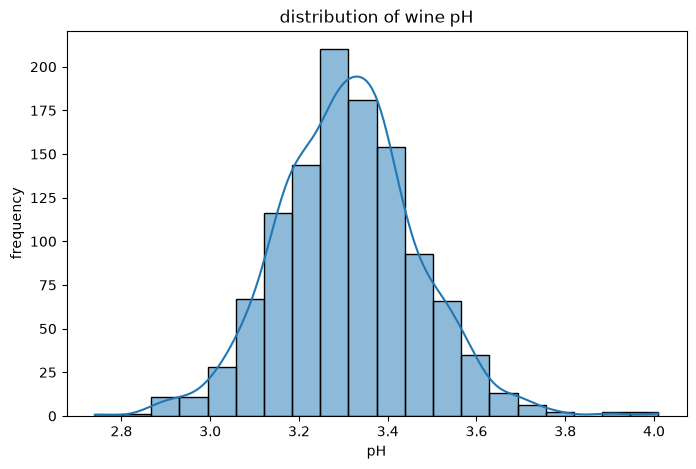

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='pH',
    bins=20,
    kde=True
)

plt.title("distribution of wine pH")
plt.xlabel("pH")
plt.ylabel("frequency")
plt.show()

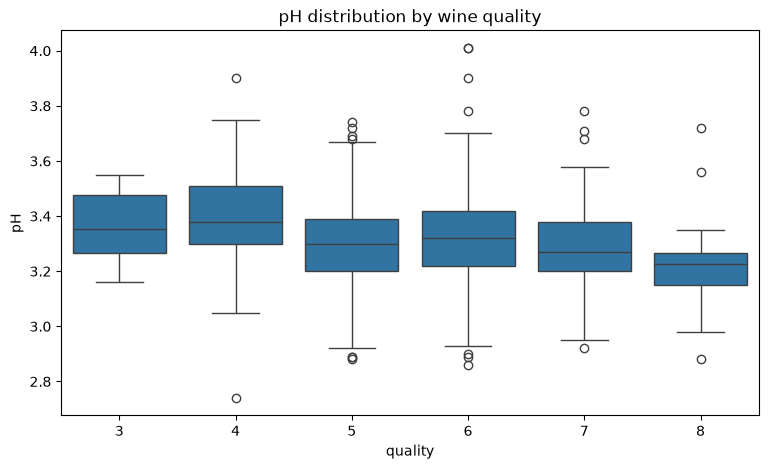

In [12]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='quality',
    y='pH'
)

plt.title("pH distribution by wine quality")
plt.xlabel("quality")
plt.ylabel("pH")
plt.show()

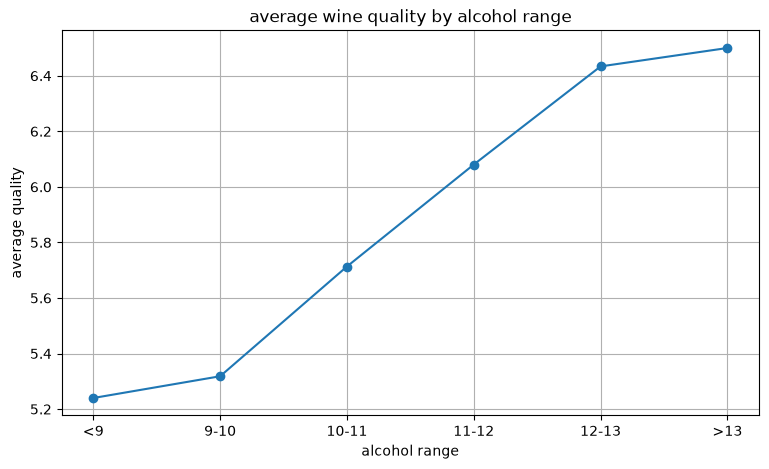

In [16]:
df['alcohol_group'] = pd.cut(
    df['alcohol'],
    bins=[0, 9, 10, 11, 12, 13, 20],
    labels=['<9', '9-10', '10-11', '11-12', '12-13', '>13']
)
avg_quality = df.groupby(
    'alcohol_group',
    observed=True
)['quality'].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    avg_quality.index,
    avg_quality.values,
    marker='o'
)

plt.title("average wine quality by alcohol range")
plt.xlabel("alcohol range")
plt.ylabel("average quality")
plt.grid()
plt.show()

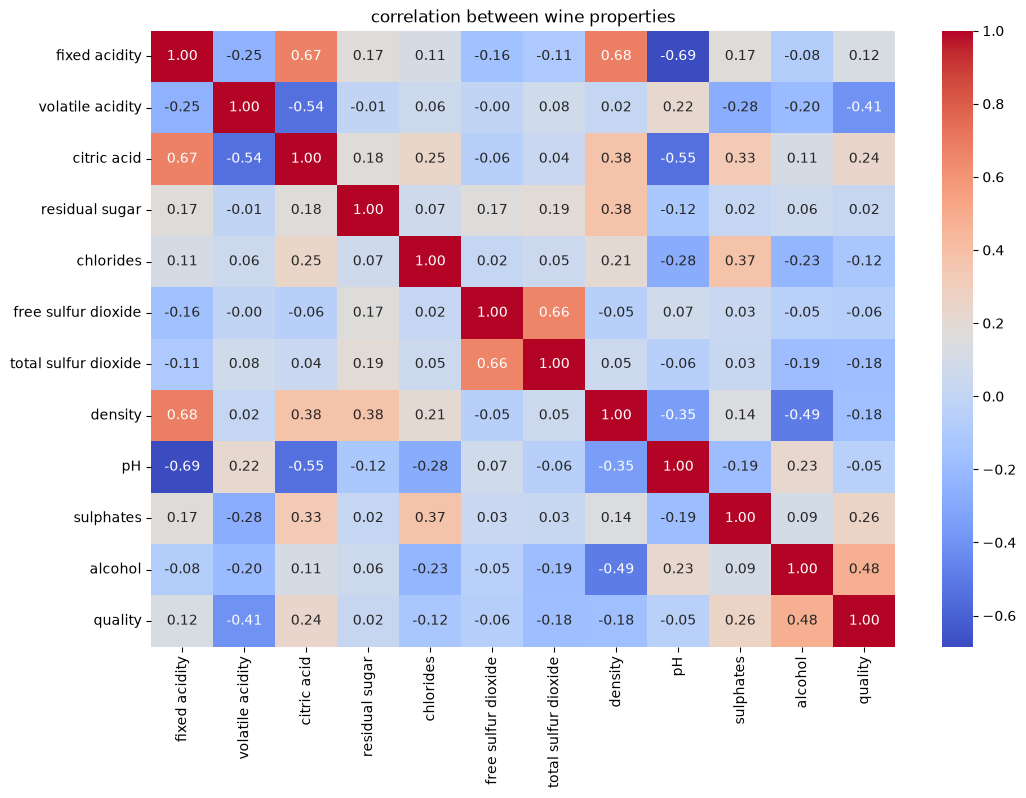

In [17]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("correlation between wine properties")
plt.show()

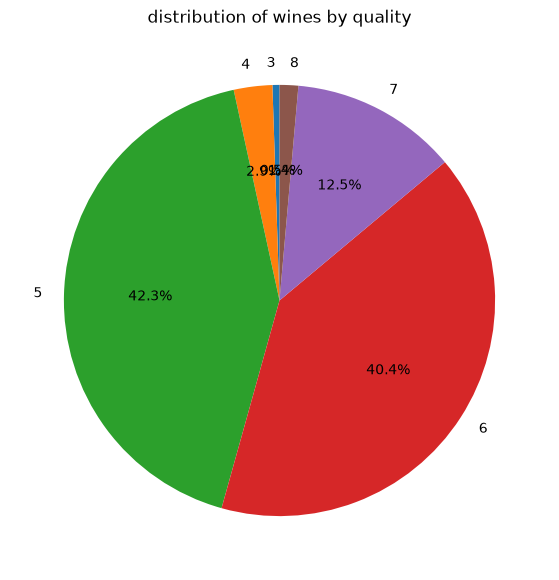

In [18]:
quality_count = df['quality'].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    quality_count.values,
    labels=quality_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("distribution of wines by quality")
plt.show()